# Previsão do Preço de Ações da NVIDIA

## Contexto

Este dataset contém informações históricas sobre os preços das ações da empresa **NVIDIA**, com dados coletados entre os anos de 2000 e 2024. O objetivo deste projeto é utilizar técnicas de aprendizado de máquina para prever o preço de fechamento das ações com base em dados passados.

## Conteúdo do Dataset

O dataset consiste nas seguintes colunas:

1. **Date**: Data em que as informações da ação foram registradas.
2. **Open**: Preço de abertura da ação no dia especificado.
3. **High**: O preço mais alto atingido pela ação durante o dia.
4. **Low**: O preço mais baixo atingido pela ação durante o dia.
5. **Close**: Preço de fechamento da ação, que será a variável alvo para as previsões.
6. **AdjClose**: Preço de fechamento ajustado, que leva em consideração fatores como dividendos e desdobramentos de ações.
7. **Volume**: Volume de ações negociadas durante o dia.

## Objetivo

O objetivo principal deste projeto é prever o preço de fechamento das ações da NVIDIA utilizando o valor da coluna **Close**. A previsão será realizada para os próximos cinco dias com base em dados históricos.

## Modelo Neural LSTM

Para este projeto, utilizaremos uma **Rede Neural Recorrente (RNN)**, especificamente a arquitetura **LSTM (Long Short-Term Memory)**. As redes LSTM são ideais para séries temporais, pois conseguem capturar dependências de longo prazo nos dados. O modelo será treinado utilizando os preços de fechamento diários, e para fazer a previsão de um dia, o modelo utilizará os valores anteriores como entrada, permitindo assim prever os preços para os próximos cinco dias.

## Importação das Bibliotecas

A seguir, iremos importar as bibliotecas necessárias para a implementação do modelo.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Conhecendo o Dataframe

In [2]:
df_nvd = pd.read_csv("NVIDIA.csv")
df_nvd.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,0.984375,0.992188,0.919271,0.975260,0.894608,30091200
1,2000-01-04,0.958333,0.960938,0.901042,0.949219,0.870721,30048000
2,2000-01-05,0.921875,0.937500,0.904948,0.917969,0.842055,18835200
3,2000-01-06,0.917969,0.917969,0.822917,0.858073,0.787112,12048000
4,2000-01-07,0.854167,0.881510,0.841146,0.872396,0.800251,7118400


Visualizando os ultimos 10 índices dos dados

In [3]:
df_nvd.tail(10)

,Date,Open,High,Low,Close,Adj Close,Volume
6106,2024-04-11,874.200012,907.390015,869.260010,906.159973,906.159973,43163700
6107,2024-04-12,896.989990,901.750000,875.299988,881.859985,881.859985,42488900
6108,2024-04-15,890.979980,906.130005,859.289978,860.010010,860.010010,44307700
6109,2024-04-16,864.330017,881.179993,860.640015,874.150024,874.150024,37045300
6110,2024-04-17,883.400024,887.750000,839.500000,840.349976,840.349976,49540000
6111,2024-04-18,849.700012,861.900024,824.020020,846.710022,846.710022,44726000
6112,2024-04-19,831.500000,843.239990,756.059998,762.000000,762.000000,87190500
6113,2024-04-22,781.039978,800.729980,764.000000,795.179993,795.179993,59634100
6114,2024-04-23,807.690002,827.690002,802.640015,824.229980,824.229980,43855900
6115,2024-04-24,839.500000,840.820007,791.830017,796.770020,796.770020,50961600


Visualização das Informações do Dataset

Ao analisar o dataset utilizando o comando `.info()`, podemos observar as informações sobre o tipo de dados de cada coluna. A seguir, estão os tipos de dados das colunas e suas implicações:

 Tipos de Dados das Colunas

1. **Date**: `object`  
   A coluna *Date* está atualmente sendo considerada como tipo `object`. No entanto, para facilitar a análise temporal, é necessário convertê-la para o tipo `datetime`, para que possamos realizar operações de data adequadas, como ordenação ou extração de partes específicas da data (dia, mês, ano, etc.).

2. **Open**: `float64`  
   A coluna *Open* contém valores do tipo `float64`, representando os preços de abertura das ações em formato numérico de ponto flutuante.

3. **High**: `float64`  
   A coluna *High* também é do tipo `float64`, armazenando os preços mais altos alcançados pelas ações durante o dia.

4. **Low**: `float64`  
   Similar à coluna *High*, a coluna *Low* é do tipo `float64`, representando os preços mais baixos das ações no dia.

5. **Close**: `float64`  
   A coluna *Close* contém os preços de fechamento das ações, sendo do tipo `float64`.

6. **Adj Close**: `float64`  
   A coluna *Adj Close* é do tipo `float64` e armazena os preços de fechamento ajustados, levando em consideração fatores como dividendos e desdobramentos de ações.

7. **Volume**: `int64`  
   A coluna *Volume* apresenta o volume de ações negociadas durante o dia, com tipo de dado `int64`, que é adequado para valores inteiros.

Necessidade de Conversão

Como mencionado, a coluna *Date* precisa ser convertida de `object` para `datetime`, permitindo que possamos manipular e analisar os dados de forma eficiente em relação ao tempo. Essa conversão é fundamental para trabalhar com séries temporais, já que o formato `datetime` oferece funcionalidades específicas para esse tipo de dado.


In [4]:
df_nvd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6116 entries, 0 to 6115
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6116 non-null   object 
 1   Open       6116 non-null   float64
 2   High       6116 non-null   float64
 3   Low        6116 non-null   float64
 4   Close      6116 non-null   float64
 5   Adj Close  6116 non-null   float64
 6   Volume     6116 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 334.6+ KB


Transformação da coluna **Date** em tipo **Datatime**

In [5]:
df_nvd["Date"]= pd.to_datetime(df_nvd["Date"], format= '%Y-%m-%d')

# Análise Exploratória

1. Qual é a relação entre o preço de abertura (Open) e o preço de fechamento (Close) das ações da NVIDIA?

    **Objetivo**: Avaliar se há uma correlação entre o preço de abertura e o fechamento das ações. Isso pode ajudar a entender se o preço de fechamento geralmente segue o preço de abertura ou se existem grandes variações ao longo do dia.

2. Como o preço das ações (Open, High, Low, Close) varia ao longo do tempo?

    **Objetivo**: Verificar as tendências e padrões de preços ao longo do tempo. Isso pode ser feito por meio de gráficos de linhas, mostrando as flutuações diárias e identificando possíveis tendências de alta ou baixa.


3. Como os preços de fechamento (Close) variam ao longo dos anos?

    **Objetivo**: O objetivo desta análise é observar como o preço de fechamento das ações da NVIDIA variou ao longo dos anos. Ao agrupar os dados por ano e calcular a média do preço de fechamento para cada período, podemos identificar tendências de longo prazo, como anos de grande valorização ou queda das ações. Essa visão é fundamental para entender o comportamento histórico das ações e pode auxiliar na previsão de tendências futuras, além de fornecer insights sobre a estabilidade ou volatilidade da empresa ao longo do tempo.

4. Existe alguma sazonalidade ou padrão específico nas variações diárias de preço (Open, High, Low, Close) em determinados meses ou anos?

      **Objetivo**: Analisar possíveis padrões sazonais ou ciclos no comportamento do preço das ações. Isso pode incluir períodos de alta ou baixa no mercado, como durante o final do ano ou após eventos específicos.

###  Qual é a relação entre o preço de abertura (Open) e o preço de fechamento (Close) das ações da NVIDIA?

**Explicação do Gráfico**:

O gráfico de dispersão mostra uma relação quase perfeita entre os preços de abertura (Open) e os preços de fechamento (Close) das ações da NVIDIA. A disposição dos pontos em uma linha reta indica que, à medida que o preço de abertura aumenta, o preço de fechamento tende a aumentar de maneira muito próxima. A correlação calculada entre essas duas variáveis foi de aproximadamente 0.9996, o que sugere uma correlação extremamente forte e positiva.

**Resultado**:

A correlação entre Open e Close foi calculada e revelou um valor muito alto, indicando que os preços de abertura e fechamento das ações da NVIDIA seguem praticamente a mesma tendência. Isso sugere que, na maioria dos dias, o comportamento do preço de fechamento está diretamente relacionado ao preço de abertura.

Correlação entre as colunas Open e Close: 0.9995978219756817


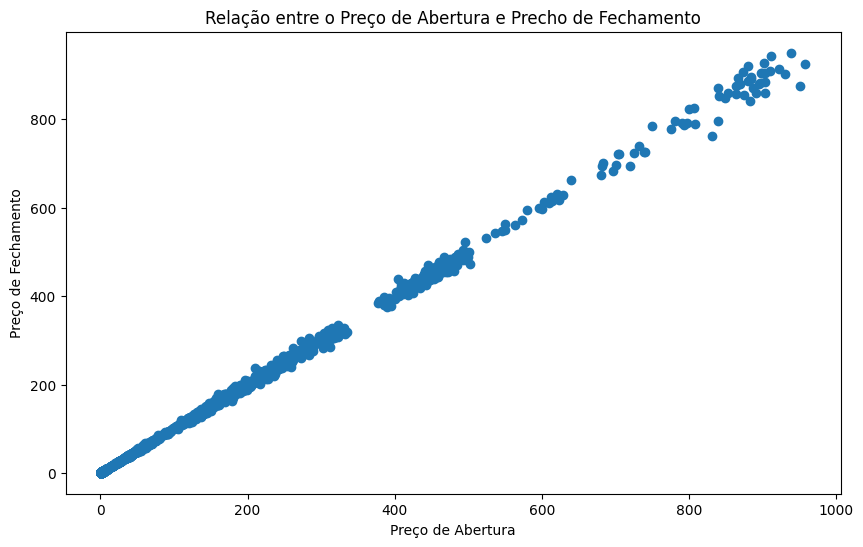

In [6]:
#Calculando a correlação entre as colunas "Open" e "Close"
correlation = df_nvd["Open"].corr(df_nvd["Close"])

#Exibindo a Correlação
print(f"Correlação entre as colunas Open e Close: {correlation}")

#Plotando o Gráfico de Dispersçao
plt.figure(figsize=(10,6))
plt.scatter(df_nvd["Open"], df_nvd["Close"])
plt.title("Relação entre o Preço de Abertura e Precho de Fechamento")
plt.xlabel("Preço de Abertura")
plt.ylabel("Preço de Fechamento")
plt.show()

###  Como o preço das ações (Open, High, Low, Close) varia ao longo do tempo?

**Explicação do Gráfico**:

O gráfico de linhas apresenta a variação dos preços de High (preço mais alto) e Low (preço mais baixo) das ações da NVIDIA ao longo do tempo. É possível observar uma leve tendência de crescimento nas primeiras décadas, com um aumento substancial nos preços a partir de 2020 até 2024. Esse aumento acentuado pode ser atribuído a eventos específicos no mercado ou a momentos de alta valorização das ações da empresa.

O gráfico também mostra uma volatilidade considerável em determinados períodos, especialmente nos últimos anos, refletindo a intensa flutuação dos preços, com picos e quedas abruptas.

**Resultado**:

O gráfico revela que as ações da NVIDIA apresentaram um crescimento expressivo desde 2020, com uma valorização acelerada até 2024. Antes desse período, os preços se mantiveram relativamente estáveis, sem grandes variações, o que pode ser característico de uma fase de maturação da empresa. A volatilidade maior no final do período analisado indica um comportamento dinâmico do mercado, possivelmente relacionado a fatores internos e externos que impactaram a empresa.


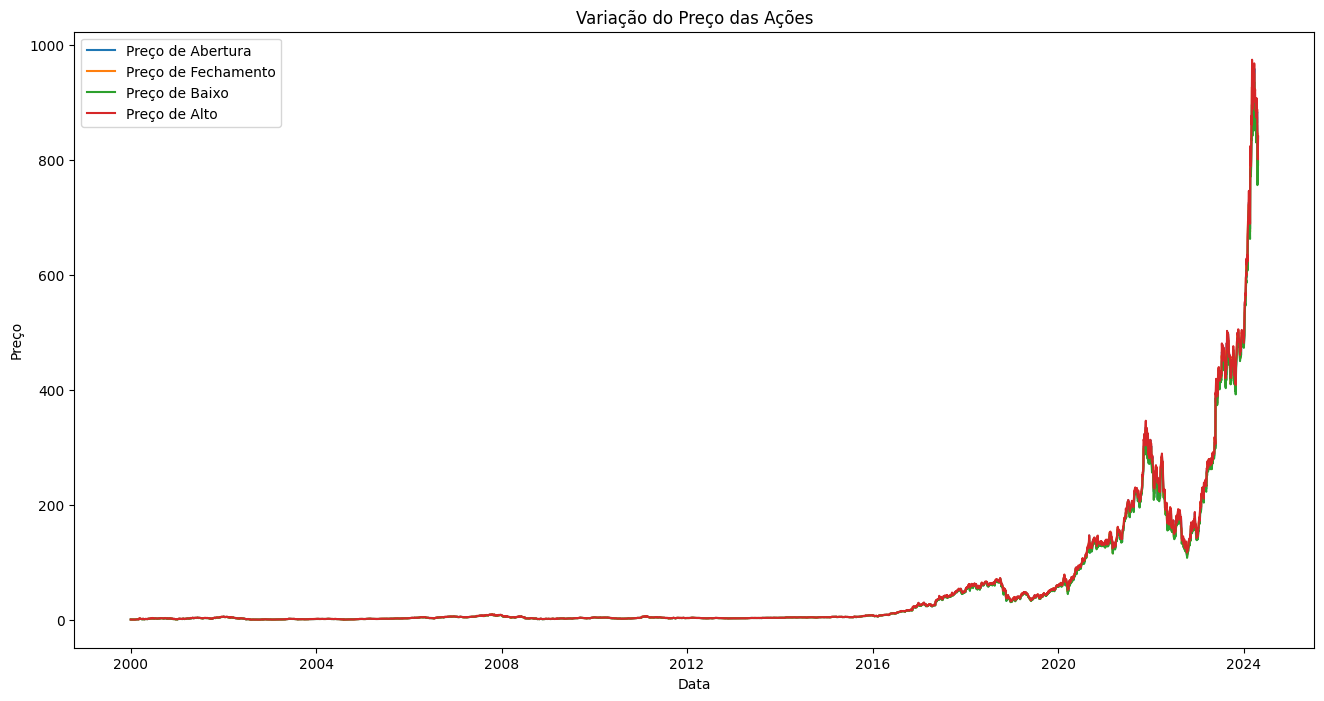

In [7]:
#Plotando Gráficos de Linha
plt.figure(figsize=(16,8))
plt.plot(df_nvd["Date"], df_nvd["Open"], label = "Preço de Abertura")
plt.plot(df_nvd["Date"], df_nvd["Close"], label = "Preço de Fechamento")
plt.plot(df_nvd["Date"],  df_nvd["Low"], label = "Preço de Baixo")
plt.plot(df_nvd["Date"], df_nvd["High"], label = "Preço de Alto")
plt.title("Variação do Preço das Ações")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.show()

### Como os preços de fechamento (Close) variam ao longo dos anos?

**Explicação do Gráfico**:

O gráfico de barras mostra a variação média anual do preço de fechamento das ações da NVIDIA. A partir da visualização, é possível observar que o preço das ações foi relativamente estável até 2016, com um aumento gradual nos anos seguintes. A partir de 2020, no entanto, os preços dispararam de maneira significativa, com uma valorização expressiva até 2024. Esse crescimento acentuado pode ser atribuído a fatores específicos do mercado e da empresa, como inovações, aumento de demanda ou outros eventos que impactaram a cotação das ações.

**Resultado**:

A análise mostra uma forte tendência de valorização das ações da NVIDIA a partir de 2020, com um aumento drástico no preço de fechamento em 2024. Isso sugere um período de crescimento acelerado, possivelmente impulsionado por mudanças no mercado, inovação tecnológica ou outros fatores que afetaram diretamente o preço das ações. Antes disso, os preços se mantiveram relativamente estáveis, indicando um período de maturação da empresa.

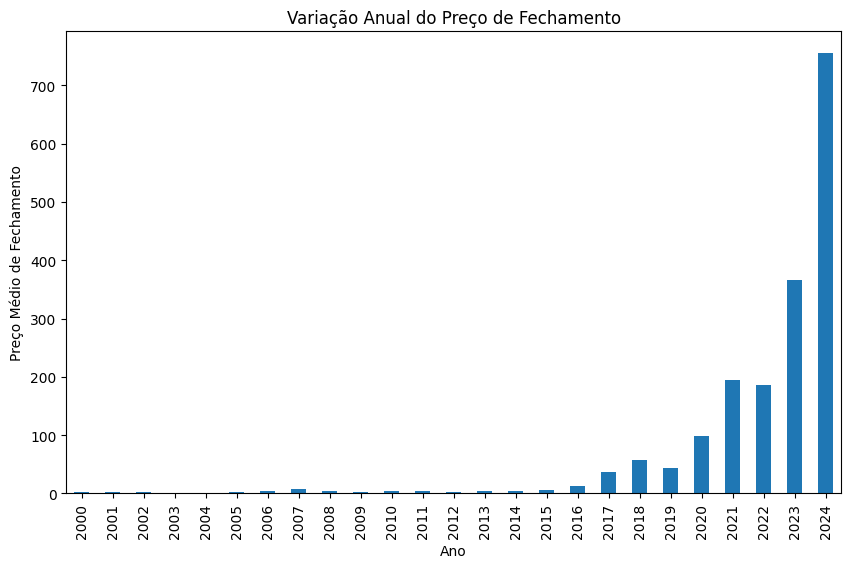

In [8]:
#Adicionando a coluna "Year"
df_nvd["Year"] = df_nvd["Date"].dt.year

#Agrupando os dados por anop e calculando a média do preço de fechamento
annual_avg_close = df_nvd.groupby("Year")["Close"].mean()

#Plotando a Variação Mensal dop Preço de Fechamento
plt.figure(figsize=(10,6))
annual_avg_close.plot(kind = "bar")
plt.title("Variação Anual do Preço de Fechamento")
plt.xlabel("Ano")
plt.ylabel("Preço Médio de Fechamento")
plt.show()

### Existe alguma sazonalidade ou padrão específico nas variações diárias de preço (Open, High, Low, Close) em determinados meses ou anos?

**Explicação do Gráfico**

O gráfico de barras mostra a variação média mensal dos preços de Open (abertura), High (máximo), Low (mínimo) e Close (fechamento) das ações da NVIDIA. Observamos que alguns meses apresentam preços médios mais elevados em comparação com outros. Por exemplo, os meses de março e novembro parecem ser mais fortes em termos de preço, com médias de preço mais altas para as quatro variáveis. Isso sugere a possibilidade de uma sazonalidade nos preços, possivelmente associada a eventos ou relatórios financeiros que afetam o desempenho das ações.

**Resultado**:

A análise revela uma leve sazonalidade, com os preços atingindo picos em determinados meses, como março e novembro, onde os preços de abertura, máximo, mínimo e fechamento são mais elevados. Isso pode estar relacionado a fatores como o lançamento de novos produtos ou divulgação de resultados financeiros da empresa, que costumam impactar positivamente as ações da NVIDIA em certos períodos do ano. No entanto, a variação não é extremamente acentuada, sugerindo que a sazonalidade não é o principal fator determinante no preço das ações.

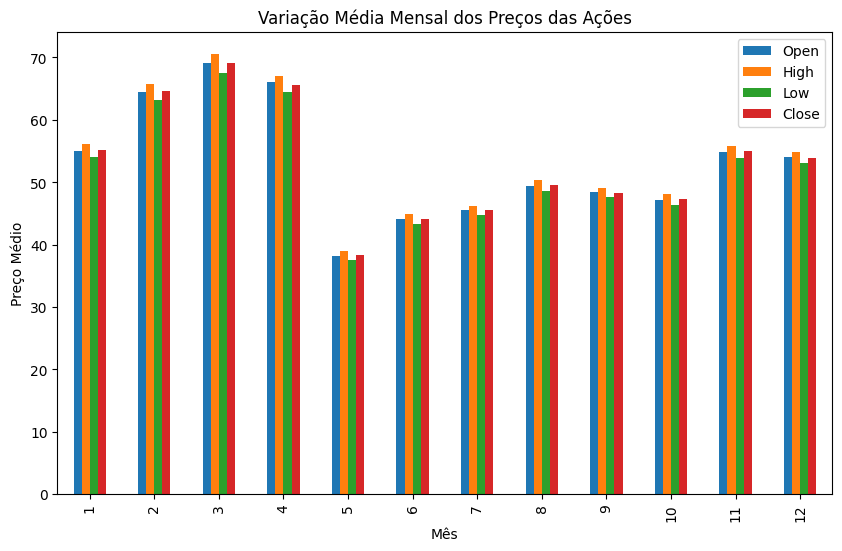

In [9]:
# Adicionando uma coluna para o mês
df_nvd["Month"] = df_nvd["Date"].dt.month

#Agrupando os dados pelo mês e calculanco a média dos preços
monthly_avg = df_nvd.groupby("Month")[["Open", "High", "Low", "Close"]].mean()

#Plotando a variação média mensal
monthly_avg.plot(kind = "bar", figsize=(10,6))
plt.title("Variação Média Mensal dos Preços das Ações")
plt.xlabel("Mês")
plt.ylabel("Preço Médio")
plt.show()

#Engenharia de Features

A engenharia de features é uma etapa fundamental no processo de construção de modelos preditivos, especialmente quando trabalhamos com modelos de aprendizado de máquina. Esse processo envolve a seleção, transformação e criação de variáveis (ou features) a partir dos dados brutos, com o objetivo de melhorar a performance do modelo e garantir que ele consiga identificar padrões relevantes.

### Por que usar dados após 2020?
A escolha de utilizar dados após 2020 para o treinamento do modelo de previsão do preço das ações da NVIDIA se baseia em uma série de considerações práticas e estratégicas. Abaixo, explicamos os principais motivos para essa decisão:

1. Fase de Crescimento e Valorização Acelerada
Após 2020, as ações da NVIDIA experimentaram um crescimento significativo, especialmente impulsionado pela demanda por tecnologia de ponta em áreas como inteligência artificial, jogos, e data centers. Utilizar esses dados pode ser vantajoso, pois esse período reflete de maneira mais precisa o comportamento atual do mercado e o impacto de inovações tecnológicas. Modelos treinados com esses dados são mais propensos a capturar tendências de valorização que podem continuar a se manifestar nos próximos anos.

2. Estabilidade e Menor Volatilidade
Embora o mercado tenha sido impactado pela pandemia de COVID-19, após 2020 o mercado passou por uma recuperação com maior estabilidade em relação a eventos de crise anteriores. Dados de períodos de alta volatilidade, como os que ocorreram em crises econômicas anteriores, podem adicionar ruído ao modelo e dificultar a aprendizagem de padrões consistentes. Focar em dados pós-2020 oferece uma oportunidade para o modelo aprender padrões de mercado mais estáveis, particularmente em um contexto de crescimento.

3. Relevância para Previsões Futuras
Usar dados pós-2020 permite que o modelo se concentre nas tendências mais recentes e nas condições atuais do mercado, que são mais relevantes para previsões futuras. As condições que influenciaram o mercado nos últimos anos, como o aumento da demanda por tecnologia de ponta, o impacto da pandemia e as políticas fiscais e monetárias, são fatores fundamentais para entender as tendências de preços das ações da NVIDIA.

4. Mudanças no Comportamento do Mercado
As ações da NVIDIA passaram a ser mais voláteis e sensíveis a novos desenvolvimentos tecnológicos após 2020, como o lançamento de novas placas de vídeo e avanços em IA. Usar dados anteriores a 2020 pode não refletir essas mudanças recentes, já que o comportamento do mercado antes de 2020 era mais estável e menos sujeito a esses novos fatores.

5. Redução de Ruído nos Dados
Os dados anteriores a 2020 contêm períodos de influências externas significativas, como a crise de 2008 e outros fatores econômicos globais, que criaram um grande ruído nos preços das ações. Ao usar dados pós-2020, você minimiza a influência de flutuações extremas e se concentra em um período mais uniforme e controlado, o que pode ajudar o modelo a focar nos padrões reais de valorização da empresa.

**Conclusão**

Optar por dados após 2020 para treinar o modelo é uma estratégia que visa melhorar a precisão da previsão, considerando que o comportamento recente do mercado é mais relevante para prever o futuro próximo. Além disso, essa abordagem permite que o modelo aprenda com tendências de crescimento mais alinhadas com a realidade atual da empresa, reduzindo o impacto de ruídos e volatilidade do passado. A engenharia de features, ao selecionar os dados mais relevantes, garante que o modelo se concentre nas informações essenciais para prever com mais confiança o preço das ações da NVIDIA no futuro.










Criando novo dataset com intervalo de tempo escolhido

In [10]:
df_nvd=df_nvd[df_nvd["Date"]>="2020-01-01"]
df_nvd.shape

(1085, 9)

Nesse dataset estarão apenas as colunas *Date* e a coluna *Close*

In [11]:
df_nvd_close = df_nvd[["Date", "Close"]]
df_nvd_close.head()

,Date,Close
5031,2020-01-02,59.977501
5032,2020-01-03,59.017502
5033,2020-01-06,59.264999
5034,2020-01-07,59.982498
5035,2020-01-08,60.095001


In [12]:
#Salavando o DataFrame
df_nvd_close.to_csv("df_nvd_close.csv", index = False)

Ajustar o índice do DataFrame para a coluna "Date" é uma prática essencial quando trabalhamos com dados temporais. Ao converter a coluna de datas em um `DatetimeIndex`, o processo se torna mais eficiente para análise de séries temporais, permitindo operações como filtragem, reamostragem e visualizações baseadas em tempo.

In [13]:
df_nvd_close = df_nvd_close.set_index(pd.DatetimeIndex(df_nvd_close["Date"].values))
df_nvd_close.head()

,Date,Close
2020-01-02,2020-01-02,59.977501
2020-01-03,2020-01-03,59.017502
2020-01-06,2020-01-06,59.264999
2020-01-07,2020-01-07,59.982498
2020-01-08,2020-01-08,60.095001


A coluna *Date* será dropada, pois ela está sendo representada pela índice

In [14]:
df_nvd_close.drop("Date", axis =1, inplace=True)
df_nvd_close.head()

,Close
2020-01-02,59.977501
2020-01-03,59.017502
2020-01-06,59.264999
2020-01-07,59.982498
2020-01-08,60.095001


**Evolução do Preço de Fechamento das Ações da NVIDIA**

Este gráfico ilustra a evolução do **preço de fechamento** das ações da **NVIDIA** ao longo do tempo, com dados de **2020 a 2024**. A análise mostra uma **valorização acentuada** nas ações da empresa a partir de 2020, refletindo a **forte demanda** por suas inovações tecnológicas e crescimento no mercado de inteligência artificial e chips gráficos.

**Conclusão**
A evolução do preço de fechamento indica que a NVIDIA passou por um período de **forte crescimento**, impulsionado pela **inovação contínua** e pela adaptação às necessidades emergentes do mercado. Esse comportamento é um indicativo de como fatores externos, como o avanço tecnológico e a adoção de novas soluções, podem impactar o valor de uma ação no mercado.

O gráfico ajuda a identificar **picos de valorização** e **momentos de estabilidade**, facilitando a previsão de possíveis tendências futuras para investidores e analistas.


Text(0, 0.5, 'Preço')

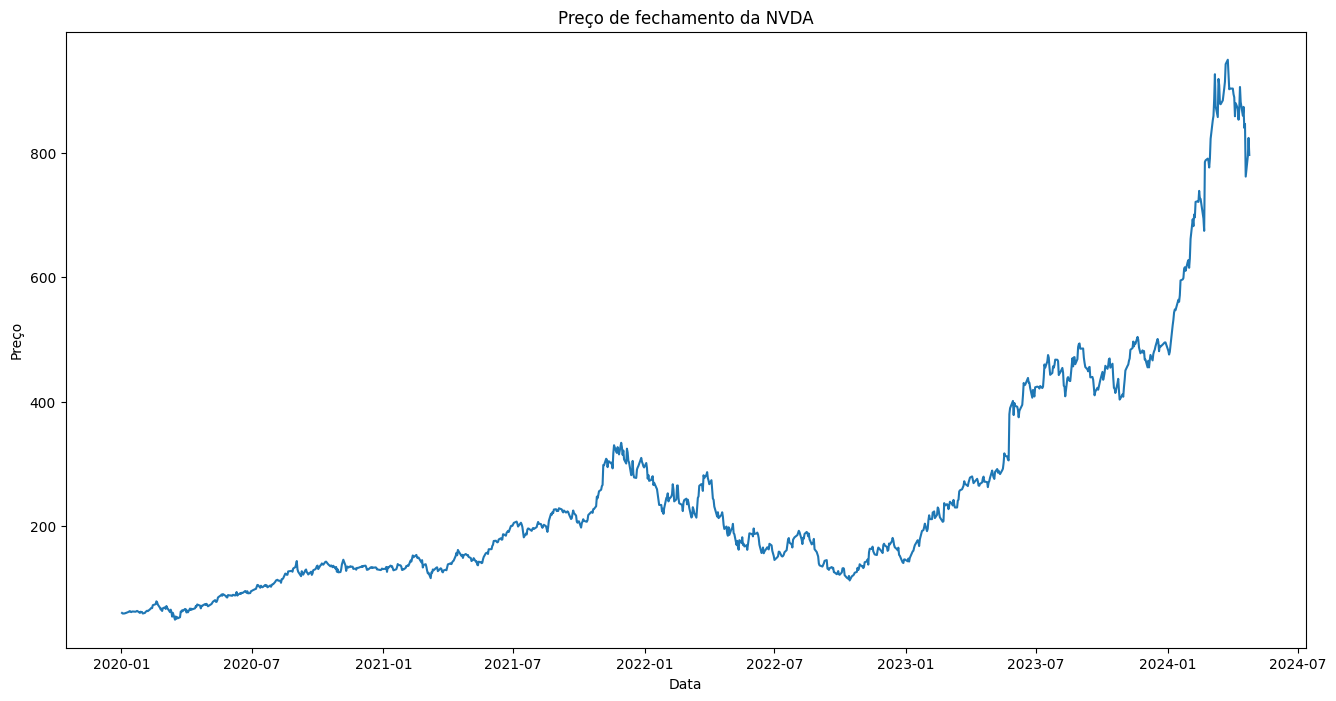

In [15]:
#Plotando o Preço de Fechamento da NVIDIA
plt.figure(figsize =(16,8))
plt.title("Preço de fechamento da NVDA")
plt.plot(df_nvd_close["Close"])
plt.xlabel("Data")
plt.ylabel("Preço")

## Divisão dos Dados em Treino e Teste

Separação dos dados de treino e teste para manter o modelo de recorrência, essa análise possibilita separar os dados de treino e teste pelo índice, ou seja nos dados de treino serão coletado dados do índice 0 até 760 e o restante dos dados serão para teste, possibilitando que o modelo aprenda a recorrência dos dados

Este código separa os dados em 70% para treino e 30% para teste, o que é uma prática comum em modelos de aprendizado de máquina para garantir que o modelo tenha dados suficientes para aprender e, ao mesmo tempo, dados separados para validação. O uso do índice para separar os dados temporais é especialmente útil em modelos de recorrência (LSTM), pois preserva a sequência temporal dos dados, permitindo que o modelo aprenda padrões e dependências ao longo do tempo.

In [16]:
#Calculando a quantidade total de linhas
quant_linhas = len(df_nvd_close)

#Separando até 70% dos dados para treino
quant_linhas_treino = round(.70 * quant_linhas)

#Separando 30% dos dados para teste
quant_linhas_test = quant_linhas - quant_linhas_treino

#Printando os Resultados
print(f"Quantidade de linhas de treino: {quant_linhas_treino}")
print(f"Quantidade de linhas de teste: {quant_linhas_test}")
print(f"Quantidade total de linhas: {quant_linhas}")

Quantidade de linhas de treino: 760
Quantidade de linhas de teste: 325
Quantidade total de linhas: 1085


## Normalização de Dados
O **StandardScaler** é uma técnica de normalização utilizada para ajustar os dados para que eles possuam uma **média de 0** e **desvio padrão de 1**. Isso é especialmente importante em modelos de aprendizado de máquina, pois as características com escalas muito diferentes podem influenciar desproporcionalmente a aprendizagem do modelo, especialmente em modelos como **redes neurais**, **K-means**, ou **SVM**, que são sensíveis à magnitude dos dados.

Essa técnica é implementada no **scikit-learn** e realiza a transformação de cada feature de forma independente, o que ajuda a garantir que as variáveis contribuem igualmente para o modelo.

## Como o **StandardScaler** Funciona?

A transformação do **StandardScaler** é dada pela fórmula:

$[
z = \frac{x - \mu}{\sigma}
$]

Onde:
- **\(x\)**: Valor original da feature.
- **\(\mu\)**: Média da feature.
- **\(\sigma\)**: Desvio padrão da feature.
- **\(z\)**: Valor transformado (normalizado).

O motivo de normalizar os dados é que os valores de fechamento podem variar consideravelmente de ano para ano, especialmente após 2020, quando a NVIDIA teve um grande crescimento. Isso pode fazer com que o modelo de LSTM aprenda a dar mais atenção aos valores maiores, em vez de se concentrar nas flutuações e tendências de longo prazo.

Com a normalização, conseguimos garantir que todas as variáveis contribuem igualmente para o modelo, evitando que as grandes variações nos preços de fechamento impactem de forma desproporcional o aprendizado do modelo.

In [17]:
# Normalização dos dados com o StandardScaler
scaler = StandardScaler()
df_nvd_close_scaled = scaler.fit_transform(df_nvd_close)
df_nvd_close_scaled

array([[-1.03141013],
       [-1.03660515],
       [-1.03526582],
       ...,
       [ 2.94712755],
       [ 3.10433113],
       [ 2.95573195]])

Separando os dados de treino (70%) e teste(30%) atráves do índice

In [18]:
#Separação dos dados de treino
train = df_nvd_close_scaled[:quant_linhas_treino]

#Seperação dos dados de teste
test = df_nvd_close_scaled[quant_linhas_treino:quant_linhas_treino + quant_linhas_test]

Verificando a quantidade de dados de treino e e teste

In [19]:
#Quantidade de dados de treino e teste
len(train) , len(test)

(760, 325)

## Explicação da Função `create_df`

A função **`create_df`** é uma implementação comum utilizada no pré-processamento de dados para modelos de aprendizado de máquina, especialmente para **modelos de séries temporais** como **Redes Neurais Recorrentes (RNN)** e **LSTM**. Seu objetivo é transformar uma série temporal em **sequências de dados** que podem ser usadas como entradas e saídas para o modelo de previsão.

## Objetivo da Função

A função cria duas variáveis:
- **`dataX`**: Contém as **sequências de entrada**, que são dados históricos de uma série temporal (preços anteriores, por exemplo).
- **`dataY`**: Contém os **valores alvo** que o modelo deve prever, ou seja, os preços futuros.

### Parâmetros:
- **`df`**: A série temporal original (um array ou DataFrame), contendo os dados que serão usados para gerar as sequências.
- **`steps`** (padrão 1): Define a **quantidade de passos (ou janelas)** temporais que serão usados para prever o próximo valor. Por exemplo, se `steps=3`, a função usará 3 pontos de dados para prever o próximo valor.

### Funcionamento:

1. **Inicialização das Listas**:
   - **`dataX`** e **`dataY`** são listas vazias que armazenarão as sequências de entrada e saída, respectivamente.

2. **Laço de Iteração**:
   A função itera pelos dados da série temporal, criando sequências de entrada e seus respectivos valores alvo:
   - Para cada índice `i`, ela seleciona uma sequência de tamanho `steps` a partir de `df[i:i+steps]`.
   - O valor subsequente `df[i+steps]` se torna o valor alvo a ser previsto.

3. **Armazenamento**:
   - As sequências de entrada (`a`) são adicionadas à lista **`dataX`**.
   - O valor futuro (`df[i+steps, 0]`) é adicionado à lista **`dataY`**.

4. **Retorno**:
   A função retorna duas **arrays do NumPy**:
   - **`dataX`**: Sequências de entrada.
   - **`dataY`**: Valores futuros a serem previstos.

In [20]:
#Criação da função
def create_df(df, steps =1):
  dataX, dataY = [], []
  for i in range(len(df)-steps-1):
    a = df[i:(i+steps), 0]
    dataX.append(a)
    dataY.append(df[i+steps,0])
  return np.array(dataX), np.array(dataY)

Abaixo é aplicação da função comentada anteriormente que é processo de preparação de dados para um modelo de aprendizado de máquina. O steps = 10: Define o número de etapas ou "passos" que podem ser usados ​​para gerar os dados. Isso indica o tamanho da janela de tempo, especialmente  lidando com dados temporais ou sequenciais.

In [21]:
#Gerando dados de treino e teste
steps = 10
X_train , Y_train = create_df(train,steps)
X_test, Y_test = create_df(test,steps)

As dimensões dos dados são uma parte importante na preparação para o treinamento de modelos de aprendizado de máquina. No código acima, estamos imprimindo as **dimensões** das variáveis de treino e teste para verificar a estrutura dos dados.

1. **`X_train.shape`**:
   - **Resultado**: `(749, 10)`

2. **`Y_train.shape`**:
   - **Resultado**: `(749,)`

3. **`X_test.shape`**:
   - **Resultado**: `(314, 10)`

4. **`Y_test.shape`**:
   - **Resultado**: `(314,)`

In [22]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(749, 10)
(749,)
(314, 10)
(314,)


#### Reshape para Modelos de Redes Neurais Recorrentes (LSTM/RNN)

Quando trabalhamos com modelos de **redes neurais recorrentes** (RNN), como **LSTM** (Long Short-Term Memory), é essencial que os dados de entrada estejam estruturados de uma maneira específica para que o modelo consiga aprender as dependências temporais. O **reshape** dos dados é um passo fundamental nesse processo. A seguir, explicamos a motivação por trás do uso do **reshape** na preparação dos dados.

Modelos como **LSTM** e **RNN** são projetados para **processar sequências de dados**. Eles são capazes de capturar as **dependências temporais** entre os elementos da sequência, o que é essencial para tarefas como **previsão de séries temporais** (ex: previsão de preços de ações). Para que o modelo possa entender o contexto de uma sequência temporal, os dados precisam ser estruturados de forma a refletir essa sequência.

Esses modelos esperam que os dados de entrada tenham **três dimensões**:
1. **Número de amostras (n_samples)**: A quantidade de exemplos que o modelo vai usar para treinamento ou teste.
2. **Número de passos de tempo (n_steps)**: A quantidade de dados temporais que serão usados para fazer a previsão (por exemplo, 10 dias anteriores).
3. **Número de features (n_features)**: A quantidade de variáveis em cada passo da sequência (por exemplo, o preço de fechamento diário de uma ação).

In [23]:
#Aplicando Reshape nos dados de treino e teste
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1],1)

Visualizando Reshape

In [24]:
X_train.shape

(749, 10, 1)

# Aplicação de Modelos LSTM para Previsão de Séries Temporais

O **LSTM (Long Short-Term Memory)** é uma arquitetura de rede neural recorrente (RNN) especializada no aprendizado de **dependências temporais**. É especialmente eficaz para trabalhar com **séries temporais**, como previsão de preços de ações, já que consegue capturar padrões e relações de longo prazo entre os dados. A seguir, explicamos a aplicação do modelo LSTM para esse tipo de tarefa.

## Arquitetura do Modelo

A arquitetura do modelo LSTM utilizado é composta por três camadas LSTM, uma camada de **Dropout** para prevenir **overfitting**, e uma camada **Dense** para realizar a previsão final. A configuração é a seguinte:

1. **3 Camadas LSTM**: São utilizadas três camadas LSTM para capturar as dependências temporais dos dados. As duas primeiras camadas têm a opção `return_sequences=True`, o que significa que elas retornam **sequências de dados** para a próxima camada LSTM. A última camada LSTM retorna apenas a **última saída** da sequência.

2. **1 Camada Dropout**: A camada **Dropout** é aplicada para prevenir o **overfitting**, ou seja, para evitar que o modelo se ajuste excessivamente aos dados de treino, o que prejudicaria sua capacidade de generalizar para dados novos.

3. **1 Camada Dense**: A camada **Dense** tem a função de gerar a **saída final**, que no caso da previsão de séries temporais será o valor futuro da variável de interesse, como o preço de fechamento das ações.


In [25]:
'''
Arquitetura do modelo
3 - Camadas LSTM sendo 2 usadas retorno de dados
1 - Camada de dropout para evitar overfitting
1 - Camada Dense
'''
modelo =Sequential()
modelo.add(LSTM(units=50, return_sequences=True, input_shape=(steps,1) ))
modelo.add(LSTM(units =50, return_sequences =True))
modelo.add(LSTM(units =50))
modelo.add(Dropout(0.2))
modelo.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Summary do Modelo LSTM

O **summary** fornecido pelo Keras detalha a arquitetura do modelo LSTM, mostrando as camadas, formas de saída e o número de parâmetros treináveis. Aqui está uma análise detalhada do summary.

## Camadas do Modelo

1. **Camada LSTM**:
   - **Output Shape**: `(None, 10, 50)`
   - **Parâmetros**: 10,400
   - A primeira camada LSTM possui **50 unidades** e retorna uma sequência de dados com **10 passos temporais** e **1 feature por passo**. A forma de saída é `(None, 10, 50)`, onde **None** representa o tamanho variável do lote (batch size).
   
2. **Camada LSTM_1**:
   - **Output Shape**: `(None, 10, 50)`
   - **Parâmetros**: 20,200
   - A segunda camada LSTM também possui **50 unidades** e retorna uma sequência de dados. Ela tem **20,200 parâmetros treináveis**, pois os parâmetros aumentam com o número de unidades e camadas.

3. **Camada LSTM_2**:
   - **Output Shape**: `(None, 50)`
   - **Parâmetros**: 20,200
   - A terceira camada LSTM retorna apenas a **última saída** da sequência (não uma sequência completa), com **50 unidades**. Ela também possui **20,200 parâmetros**, pois o número de unidades permanece o mesmo da camada anterior.

4. **Camada Dropout**:
   - **Output Shape**: `(None, 50)`
   - **Parâmetros**: 0
   - A camada **Dropout** é usada para evitar **overfitting**, desligando aleatoriamente 20% das unidades durante o treinamento. Ela não tem parâmetros treináveis, por isso o número de parâmetros é **0**.

5. **Camada Dense**:
   - **Output Shape**: `(None, 1)`
   - **Parâmetros**: 51
   - A camada **Dense** possui **1 unidade** de saída, representando o valor que será previsto. Ela tem **51 parâmetros**: 50 unidades da camada anterior + 1 viés.

## Parâmetros Totais

- **Total de Parâmetros**: 50,851 (198.64 KB)
  - O modelo tem **50,851 parâmetros** no total, que são ajustados durante o treinamento.
  
- **Parâmetros Treináveis**: 50,851 (198.64 KB)
  - Todos os parâmetros são **treináveis**, ou seja, o modelo ajustará esses valores para minimizar o erro.

- **Parâmetros Não Treináveis**: 0 (0.00 B)
  - Não existem parâmetros **não treináveis** no modelo, o que significa que todas as camadas possuem pesos que serão ajustados durante o treinamento.


In [26]:
modelo.compile(optimizer="adam", loss="mse")
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

### Análise dos Resultados das Métricas de Treinamento

Durante o treinamento do modelo, as duas principais métricas acompanhadas são o **`loss`** (erro de treinamento) e o **`val_loss`** (erro de validação). Abaixo, fazemos uma análise detalhada desses resultados ao longo das 40 epochs de treinamento.

## Comportamento das Métricas

### 1. **Perda de Treinamento (`loss`)**
- A **`loss`** diminui de **0.0895** na **Epoch 1** para **0.0027** na **Epoch 39**, indicando que o modelo está aprendendo de forma eficiente e ajustando seus parâmetros conforme o treinamento avança. A **queda consistente da `loss`** sugere que o modelo está se ajustando bem aos dados de treinamento.
- A diminuição gradual da **`loss`** após as primeiras épocas é um bom sinal de que o modelo está encontrando padrões nos dados e **minimizando o erro de previsão** durante o treinamento.

### 2. **Perda de Validação (`val_loss`)**
- A **`val_loss`** começa em **0.9902** na **Epoch 1**, mas ao longo das épocas, ela diminui consideravelmente, chegando a **0.0483** na **Epoch 40**. Essa queda mostra que o modelo **também está se ajustando bem aos dados de validação**, embora de maneira um pouco mais volúvel, com alguns aumentos em determinadas épocas.
- A flutuação observada na **`val_loss`** nas primeiras 20 epochs, com algumas **oscilações para cima**, pode ser normal em modelos de aprendizado profundo, especialmente em dados de validação que não fazem parte do treinamento. Isso pode ocorrer devido a **dificuldades temporárias** do modelo em melhorar a generalização em dados que não foram usados diretamente no treinamento.

## Análise Geral

### 1. **Ajuste ao Treinamento:**
- O modelo está **aprender de forma eficiente**, com a **`loss`** diminuindo de forma consistente, o que significa que ele está melhorando a capacidade de prever os valores do conjunto de treinamento.

### 2. **Oscilações na `val_loss`:**
- A **`val_loss`** apresenta algumas **oscilações**, mas a tendência de **diminuição** ao longo das épocas sugere que o modelo está **generalizando bem** para os dados de validação, mesmo com algumas variações. Isso indica que o modelo está aprendendo a prever os dados futuros com base nas entradas anteriores, mas ainda há oportunidades para **melhorar a generalização**.




In [27]:
validacao = modelo.fit(X_train, Y_train, validation_data=(X_test, Y_test),epochs=40,batch_size = 10, verbose=1)

Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0999 - val_loss: 0.8981
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0095 - val_loss: 0.7914
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0084 - val_loss: 0.7127
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0085 - val_loss: 0.6631
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0075 - val_loss: 0.6826
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0075 - val_loss: 0.5954
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0099 - val_loss: 0.6982
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0067 - val_loss: 0.5500
Epoch 9/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0067 - val_loss: 0.4080
Epoch 10/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0061 - val_loss: 0.3459
Epoch 11/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0066 - val_loss: 0.4436
Epoch 12/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

### Análise do Gráfico de Função de Perda (Loss)

O gráfico acima mostra a **evolução da função de perda (loss)** tanto para os dados de **treinamento** quanto para os dados de **validação** ao longo das **epochs**. A análise dessa curva é crucial para avaliar o desempenho do modelo e identificar problemas como **overfitting** ou **underfitting**.

### Interpretação do Gráfico

1. **Curva de Treinamento (Azul) - `loss`:**
   - A **curva de treinamento** (representada pela linha azul) apresenta uma **diminuição acentuada** ao longo das épocas, indicando que o modelo está **aprendendo e ajustando os parâmetros** de forma eficiente durante o treinamento.
   - Essa diminuição contínua sugere que o modelo está se ajustando aos dados de treinamento e conseguindo **minimizar o erro** em cada iteração.

2. **Curva de Validação (Laranja) - `val_loss`:**
   - A **curva de validação** (representada pela linha laranja) mostra uma **queda mais suave** nos primeiros momentos, mas também apresenta **flutuações**.
   - Em algumas **épocas iniciais**, o erro de validação (val_loss) começa alto, mas diminui progressivamente. Isso sugere que o modelo está **geralizando bem para os dados de validação** à medida que o treinamento avança.
   - No entanto, é possível observar uma **leve oscilação** da **`val_loss`** depois da **epoch 10**, o que pode indicar **flutuações** no ajuste do modelo.


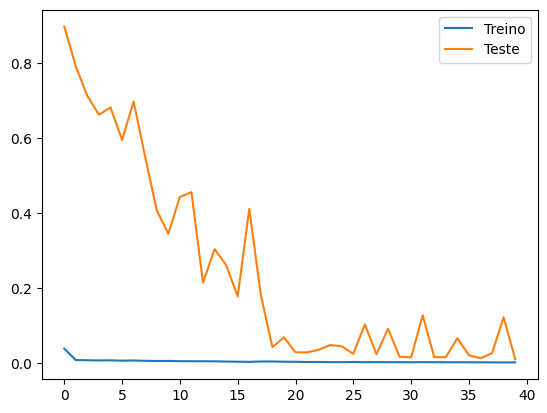

In [28]:
#Plotando Gráfico de Análise de Erro
plt.plot(validacao.history["loss"], label="Treino")
plt.plot(validacao.history["val_loss"], label="Teste")
plt.legend()

# Análise de Métricas de Regressão


Ao treinar um modelo de aprendizado de máquina, é essencial avaliar seu desempenho por meio de **métricas de avaliação**. Duas das métricas mais comuns para problemas de **regressão** (como previsão de preços) são o **Erro Quadrático Médio (MSE)** e o **Coeficiente de Determinação (R²)**. Vamos explorar essas métricas e outras que podem oferecer um **embasamento completo** para avaliar a performance do modelo.

## 1. **Erro Quadrático Médio (MSE - Mean Squared Error)**

### **Definição**:
O **MSE** mede a **média dos quadrados das diferenças** entre os valores previstos pelo modelo e os valores reais observados. O cálculo é dado por:

$[
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$]

Onde:
- $( y_i $) é o valor real (observado).
- $( \hat{y}_i $) é o valor predito pelo modelo.
- $( n $) é o número total de amostras.

### **Interpretação**:
- **MSE baixo**: Quanto mais próximo de zero for o MSE, melhor será o desempenho do modelo, pois indica que as previsões estão mais próximas dos valores reais.
- **MSE alto**: Um MSE elevado sugere que o modelo tem **grande erro nas previsões**, o que pode indicar **subajuste** ou **overfitting**.

### **Quando usar**:
O MSE é útil quando se deseja **penalizar mais erros maiores**. Se um modelo tiver grandes erros de previsão, o MSE aumentará significativamente devido ao **quadrado da diferença**.

## 2. **Coeficiente de Determinação (R² - R-Squared)**

### **Definição**:
O **R²** mede a **proporção da variabilidade nos dados** que é explicada pelo modelo. Ele varia entre 0 e 1, onde:
- **R² = 1** indica que o modelo **explica 100%** da variabilidade nos dados.
- **R² = 0** indica que o modelo não é melhor do que uma simples média para prever os valores.
  
A fórmula para o cálculo do **R²** é:

$[
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$]

Onde:
- $( \bar{y} $) é a média dos valores reais.

### **Interpretação**:
- **R² próximo de 1**: O modelo é muito bom em explicar a variabilidade dos dados.
- **R² baixo (próximo de 0)**: O modelo não está explicando bem os dados e pode precisar de ajustes, como a adição de mais features ou um modelo diferente.

### **Quando usar**:
O **R²** é útil para entender o **quanto o modelo consegue explicar** da variabilidade dos dados. Contudo, é importante observar que, embora útil, ele pode ser afetado por **outliers** ou **modelos superajustados**.


### 3. **Erro Absoluto Médio (MAE - Mean Absolute Error)**
- O **MAE** calcula a **média das diferenças absolutas** entre os valores previstos e os valores reais. Ele é dado por:

$[
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$]

- **MAE baixo** indica que o modelo tem boas previsões, sem penalizar excessivamente os erros maiores, como o **MSE** faz.


### 4. **Erro Absoluto Médio Percentual (MAPE - Mean Absolute Percentage Error)**
- O **MAPE** mede o **erro absoluto em termos percentuais**, o que torna a métrica mais **intuitiva** para problemas em que a magnitude dos valores varia muito. Sua fórmula é:

$[
MAPE = \frac{1}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100
$]

- **MAPE baixo** significa que o modelo está fazendo previsões muito próximas aos valores reais, e pode ser útil especialmente quando se trabalha com **grandes variações** de dados.



In [29]:
#Aplicando predição dos dados
previsao = modelo.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


O resultado da métrica **Erro Quadrático Médio (MSE)** para o modelo foi calculado como **0.011655**.

- **Valor baixo de MSE**: O valor de **0.0115** indica que o modelo está fazendo boas previsões, com erros médios pequenos. A medida **não é muito alta**, o que sugere que o modelo tem um desempenho razoável para a tarefa de previsão.

- **Comparação com outras métricas**: Para obter uma visão mais completa da qualidade do modelo, o **MSE** deve ser analisado em conjunto com outras métricas, como **R²**, **MAE** ou **RMSE**, que fornecem uma visão mais clara de como o modelo está se saindo, especialmente em relação à sua capacidade de generalizar para novos dados.

In [30]:
#Aplicando o Calculo do MSE
mse=mean_squared_error(Y_test,previsao)

#Exibindo o o Valor de MSE
print("MSE: ", mse)


MSE:  0.01157226543497286


O valor do **Erro Absoluto Médio (MAE)** calculado foi de **0.0733**.

- **MAE baixo**: O valor **0.0733** é relativamente **baixo**, o que indica que o modelo está fazendo boas previsões, com erros médios pequenos. Em outras palavras, as previsões feitas pelo modelo estão **muito próximas** dos valores reais.



In [31]:
from sklearn.metrics import mean_absolute_error

# Calculando o MAE
mae = mean_absolute_error(Y_test, previsao)

# Exibindo o valor do MAE
print("MAE: ", mae)


MAE:  0.07334238611731791


O valor do **R² (Coeficiente de Determinação)** calculado foi de **0.9897**.

- **R² alto (próximo de 1)**: O valor de **0.9897** indica que o modelo **explica 98.96%** da variabilidade nos dados, o que é um **excelente resultado**. Isso sugere que o modelo está **capturando muito bem os padrões dos dados**, com um erro muito baixo nas previsões.
- **Capacidade de previsão**: Esse valor elevado de **R²** indica que o modelo é muito bom em prever os valores futuros com base nas entradas, sendo um ótimo indicador de **precisão e eficácia**.

In [33]:
print(r2_score(Y_test,previsao))

0.9897311402685929


*Salvando* os Modelo

In [34]:
#Salvando o Modelo
modelo.save('modelo_lstm.h5')

#Salvando o Scalaer
import pickle
with open('scaler.pkl', 'wb') as file:
  pickle.dump(scaler, file)

##Previsão de valores futuros
Neste processo, o objetivo é usar **10 dias de dados anteriores** para prever os **5 dias seguintes**. Abaixo está o fluxo de operações realizadas para realizar essa previsão, desde a preparação dos dados até a criação de um DataFrame final com as previsões.


Verificando o tamanho dos de teste

In [35]:
lenght_test = len(test)
lenght_test

325

Iremos criar uma variável que vai receber os dias de entradas, ou seja o modelo irá coletar 10 dias com frequencia e analisar sua recorrência

In [36]:
days_inputs = lenght_test -steps
days_inputs

315

Após separar os dias de entrada, iremos fatiar os dados de teste a partir de um determinado ponto definido por days_inputs = 10, converte a fatia resultante em um array NumPy, e então ajusta a forma do array para ter uma única linha (ou seja, um vetor de linha).

In [37]:
#Transformar em arrays
inputs_steps = test[days_inputs:]
inputs_steps = np.array(inputs_steps).reshape(1,-1)
inputs_steps

array([[3.54769411, 3.41619507, 3.29795425, 3.37447273, 3.19156426,
        3.22598155, 2.76757449, 2.94712755, 3.10433113, 2.95573195]])

Convertendo em uma lista com dados normalizados

In [38]:
list_output = list(inputs_steps)
list_output = list_output[0].tolist()
list_output

[3.5476941063808,
 3.416195072007533,
 3.2979542476260546,
 3.374472729323432,
 3.1915642573616316,
 3.225981554504723,
 2.767574492956454,
 2.9471275462341655,
 3.1043311316456466,
 2.955731954397965]

Abaixo vai ser possível obersvar o loop que funciona basicamente pegando os últimos *steps* dias de dados, usando-os para prever o próximo dia, adicionando a previsão ao conjunto de dados e repetindo o processo para o próximo dia até que 5 dias sejam previstos.

Um loop é utilizado para prever os 5 dias seguintes. A cada iteração, o modelo usa os últimos 10 dias (com steps = 10) para prever o próximo dia. Após prever o valor, ele é adicionado ao conjunto de dados para ser utilizado na próxima iteração.

In [39]:
#loop para prever os 5 dias
pred_output = [] #Lista para armazenar as previsões
i =0 #Controle de inicialização
n_future =5 #Número de dias de predição

#Iniciando o loop para previsão
while(i<n_future):
   #Se a lista de saídas tiver dados suficientes (maior que 'steps'), continue o processo
  if(len(list_output)>steps):
    # Cria os dados de entrada a partir dos últimos valores disponíveis
    inputs_steps = np.array(list_output[1:])
    print(f"{i} dia Valores de entrada --> {inputs_steps}")

     #Cria os dados de entrada a partir dos últimos valores disponíveis
    inputs_steps = inputs_steps.reshape(1,-1)
    inputs_steps = inputs_steps.reshape(1,steps,1)
    pred = modelo.predict(inputs_steps, verbose =0)
    print(f"{i} Dia , Valor previsto --> {pred}")

    #Atualiza a lista de entradas, removendo o primeiro valor e adicionando a previsão
    list_output.extend(pred[0].tolist())
    list_output = list_output[1:]
    pred_output.extend(pred.tolist())
    i= i +1

  else:
    # Caso não haja dados suficientes para a previsão, faz a previsão com os dados iniciais
    #Ajustando os dados e fazendo previsão
    inputs_steps = inputs_steps.reshape((1,steps,1))
    pred = modelo.predict(inputs_steps, verbose = 0)
    print(pred[0])

    #Adicionando a previsão em lista
    list_output.extend(pred[0].tolist())
    print(len(list_output))

    #Adiciona a previsão ao resultado final
    pred_output.extend(pred.tolist())
    i = i +1

print(pred_output)



[3.0046005]
11
1 dia Valores de entrada --> [3.41619507 3.29795425 3.37447273 3.19156426 3.22598155 2.76757449
 2.94712755 3.10433113 2.95573195 3.00460052]
1 Dia , Valor previsto --> [[3.018831]]
2 dia Valores de entrada --> [3.29795425 3.37447273 3.19156426 3.22598155 2.76757449 2.94712755
 3.10433113 2.95573195 3.00460052 3.01883101]
2 Dia , Valor previsto --> [[3.0421612]]
3 dia Valores de entrada --> [3.37447273 3.19156426 3.22598155 2.76757449 2.94712755 3.10433113
 2.95573195 3.00460052 3.01883101 3.04216123]
3 Dia , Valor previsto --> [[3.0685434]]
4 dia Valores de entrada --> [3.19156426 3.22598155 2.76757449 2.94712755 3.10433113 2.95573195
 3.00460052 3.01883101 3.04216123 3.06854343]
4 Dia , Valor previsto --> [[3.097034]]
[[3.0046005249023438], [3.0188310146331787], [3.042161226272583], [3.0685434341430664], [3.097033977508545]]


Prevendo a saída e transformando os dados normalizado para valores normais

In [40]:
#Transformando os dados em  suas escalas reais
previsao = scaler.inverse_transform(pred_output)

#Aplicando o Resahpe dos Dados
previsao = np.array(previsao).reshape(1,-1)

#Transformando em Listas
list_output = list(previsao)
list_output = list_output[0].tolist()
list_output


[805.8005477334794,
 808.43023038736,
 812.7414701282217,
 817.6166947845983,
 822.8815232694176]

Neste trecho de código, a ideia é **capturar os próximos dias** após o **último valor de data** presente no DataFrame. Vamos analisar como isso é feito:

Obter **5 dias úteis seguintes** a partir do **último dia presente** no DataFrame (`df_nvd`), com base na coluna **"Date"**.


In [41]:
#Obtendo os 5 dias futuros
dates = pd.to_datetime(df_nvd["Date"])
predict_dates = pd.date_range(list(dates)[-1] + pd.DateOffset(1), periods=5, freq="b").tolist()
predict_dates


[Timestamp('2024-04-25 00:00:00'),
 Timestamp('2024-04-26 00:00:00'),
 Timestamp('2024-04-29 00:00:00'),
 Timestamp('2024-04-30 00:00:00'),
 Timestamp('2024-05-01 00:00:00')]

Criando um dataframe dos valores dos futuros

In [42]:
#Criar dataframe de previsão
forecast_dates = []
for i in predict_dates:
  forecast_dates.append(i.date())

#Transformando em DataFrame
df_forecast = pd.DataFrame({"Date" : np.array(forecast_dates), "Close":list_output })
df_forecast["Date"] = pd.to_datetime(df_forecast["Date"])

#Alocando o index da data no dataframe
df_forecast = df_forecast.set_index(pd.DatetimeIndex(df_forecast["Date"].values))
df_forecast.drop("Date", axis =1, inplace = True)
df_forecast


,Close
2024-04-25,805.800548
2024-04-26,808.430230
2024-04-29,812.741470
2024-04-30,817.616695
2024-05-01,822.881523


Plotando a tendência dos valores para os proximos dias futuros

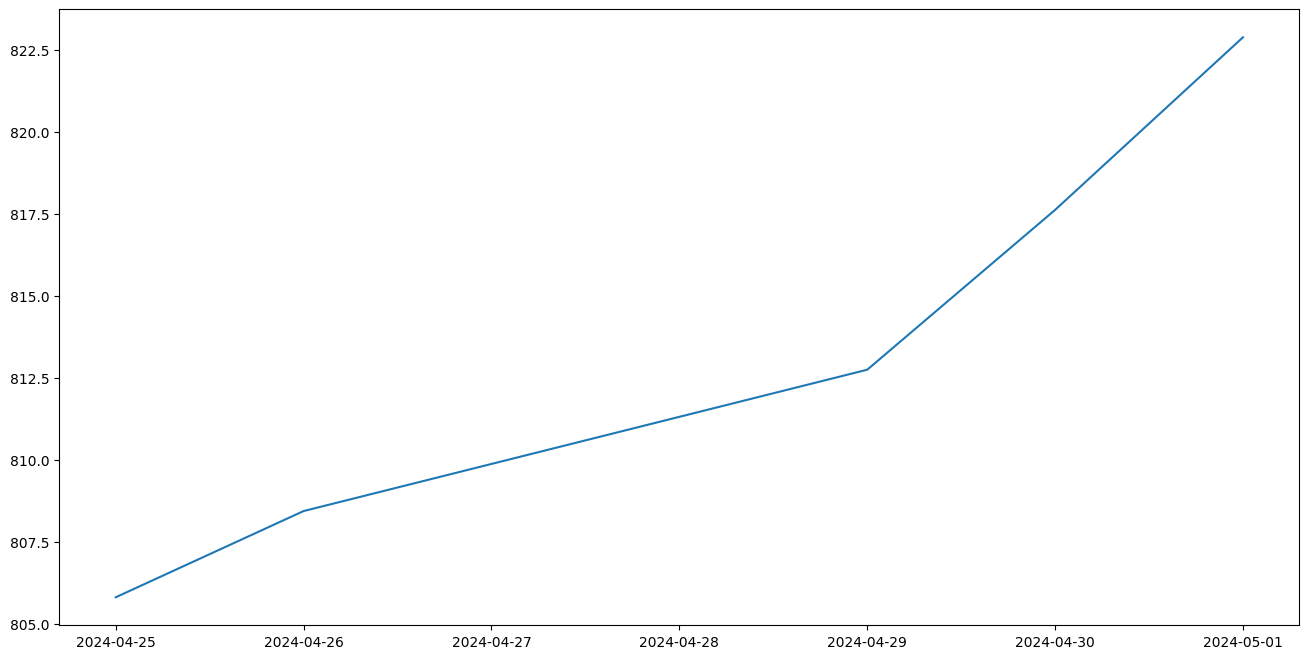

In [43]:
plt.figure(figsize=(16,8))
plt.plot(df_forecast["Close"])

Capturando os últimos 10 dias do dataframe da *NVIDIA*

In [44]:
df_nvd_close_end = df_nvd_close.tail(10)
df_nvd_close_end

,Close
2024-04-11,906.159973
2024-04-12,881.859985
2024-04-15,860.010010
2024-04-16,874.150024
2024-04-17,840.349976
2024-04-18,846.710022
2024-04-19,762.000000
2024-04-22,795.179993
2024-04-23,824.229980
2024-04-24,796.770020


Análise dos valores dos dados com valores futuros

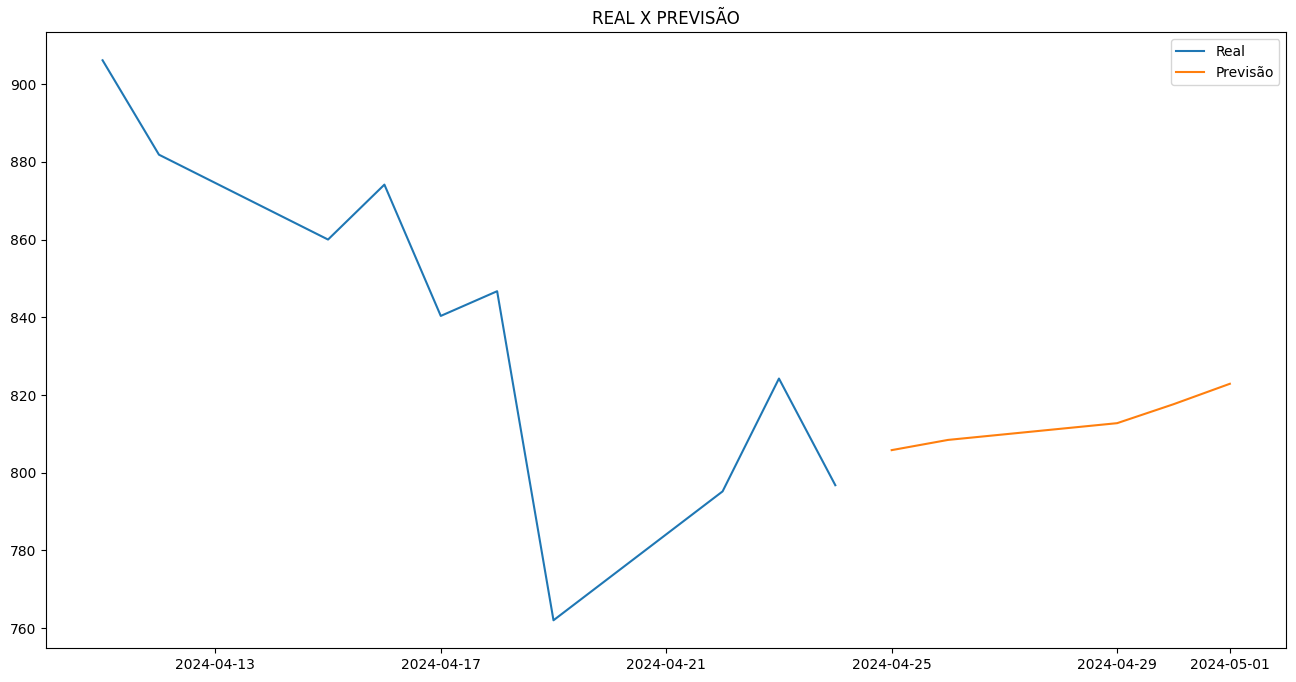

In [45]:
#Plotar gráfico
plt.figure(figsize=(16,8))
plt.plot(df_nvd_close_end["Close"])
plt.plot(df_forecast["Close"])
plt.legend(["Real", "Previsão"])
plt.title('REAL X PREVISÃO')
plt.show()

## CONCLUSÃO

Este projeto utiliza o modelo neural **LSTM (Long Short-Term Memory)**, um tipo especial de rede neural recorrente (RNN) projetada para aprender e reter informações em sequências temporais de dados. Os dados foram retirados da plataforma do Kaggle: [Nvidia Corporation](https://www.kaggle.com/datasets/prajwaldongre/nvidia-corp-share-price-2000-2024).

### **Previsões (obtidas pelo modelo)**:
- 25/04/2024: R$805.80

- 26/04/2024: R$808.43

- 29/04/2024: R$812.74

- 30/04/2024: R$817.62

- 01/05/2024: R$822.88

### **Valores Reais (obtidos pela pesquisa)**:

- 25/04/2024: R$846.71

- 26/04/2024: R$762.00

- 29/04/2024: R$795.18

- 30/04/2024: R$824.23

- 01/05/2024: R$796.77

### **Comparação dos Resultados**:

Ao comparar os valores previstos e reais, é possível observar que o modelo **subestimou** os preços de fechamento da ação da NVIDIA. Em todos os dias analisados, os valores reais são **superiores** às previsões feitas pelo modelo.

- **Diferenças em Reais**:
  - 25/04/2024: Previsão 805.80 vs Real 846.71 → **Diferença de R$40.91**
  
  - 26/04/2024: Previsão 808.43 vs Real 762.00 → **Diferença de R$46.43**
  
  - 29/04/2024: Previsão 812.74 vs Real 795.18 → **Diferença de R$17.56**
  
  - 30/04/2024: Previsão 817.62 vs Real 824.23 → **Diferença de R$6.61**
  
  - 01/05/2024: Previsão 822.88 vs Real 796.77 → **Diferença de R$26.11**
